In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: Load the Titanic Dataset

The Titanic training dataset was uploaded and loaded into a Pandas DataFrame. This dataset will be used to train and compare Logistic Regression, Random Forest, and XGBoost models.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Step 3: Explore the Dataset

The dataset was explored using `df.info()` to understand its structure, data types, and available values. Missing values were checked using `df.isnull().sum()`.

The dataset contains missing values in the `Age`, `Cabin`, and `Embarked` columns. These missing values will be handled during data preprocessing.

In [7]:
# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [8]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [9]:
# Convert categorical columns into numerical values
df["Sex"] = LabelEncoder().fit_transform(df["Sex"])

df["Embarked"] = LabelEncoder().fit_transform(df["Embarked"])

In [10]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB

Missing values:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


## Step 4: Data Cleaning and Preprocessing

Missing values in the `Age` and `Embarked` columns were handled using the median and mode, respectively. Unnecessary columns such as `PassengerId`, `Name`, `Ticket`, and `Cabin` were removed.

The categorical columns `Sex` and `Embarked` were converted into numerical values using LabelEncoder so that the machine learning models can process them.

In [12]:
# Select input features and target variable
X = df.drop("Survived", axis=1)

y = df["Survived"]

In [13]:
print("Features:")
print(X.columns)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

Feature shape: (891, 7)
Target shape: (891,)


## Step 5: Select Features and Target Variable

The dataset was divided into input features (`X`) and the target variable (`y`).

The input features contain passenger information that will be used by the machine learning models. The target variable is `Survived`, which indicates whether a passenger survived (`1`) or did not survive (`0`).

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (712, 7)
Testing features shape: (179, 7)
Training target shape: (712,)
Testing target shape: (179,)


## Step 6: Split the Dataset

The dataset was divided into training and testing sets using an 80:20 ratio. The training data will be used to train Logistic Regression, Random Forest, and XGBoost models, while the testing data will be used to evaluate and compare their performance.

The same train-test split will be used for all models to ensure a fair comparison.

In [15]:
# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
logistic_predictions = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, logistic_predictions)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.8044692737430168


## Step 7: Logistic Regression Baseline Model

A Logistic Regression model was trained using the training dataset and evaluated on the testing dataset. Its accuracy will serve as the baseline score for comparing the performance of the Random Forest and XGBoost ensemble models.

In [16]:
# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
random_forest_predictions = random_forest_model.predict(X_test)

# Calculate accuracy
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Accuracy:", random_forest_accuracy)

Random Forest Accuracy: 0.8268156424581006


## Step 8: Random Forest Classifier

A Random Forest Classifier was trained using 100 decision trees. The model was evaluated on the same testing dataset used for Logistic Regression to ensure a fair comparison.

Random Forest is an ensemble learning method that combines the predictions of multiple decision trees to produce a more reliable final prediction.

In [17]:
# Create the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_predictions = xgb_model.predict(X_test)

# Calculate accuracy
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.7821229050279329


## Step 9: XGBoost Classifier

An XGBoost Classifier was trained and evaluated using the same training and testing datasets. XGBoost is a boosting ensemble method that builds decision trees sequentially, with each new tree attempting to correct the errors made by the previous trees.

The model's accuracy will be compared with Logistic Regression and Random Forest.

In [18]:
# Create a comparison table
comparison_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Metric": [
        "Accuracy",
        "Accuracy",
        "Accuracy"
    ],
    "Score": [
        logistic_accuracy,
        random_forest_accuracy,
        xgb_accuracy
    ]
})

# Convert scores to percentages
comparison_results["Score (%)"] = (
    comparison_results["Score"] * 100
).round(2)

# Display the comparison table
comparison_results

,Model,Metric,Score,Score (%)
0,Logistic Regression,Accuracy,0.804469,80.45
1,Random Forest,Accuracy,0.826816,82.68
2,XGBoost,Accuracy,0.782123,78.21


## Step 10: Model Performance Comparison

The performance of Logistic Regression, Random Forest, and XGBoost was compared using accuracy as the evaluation metric.

Random Forest achieved the highest accuracy of **82.68%**, followed by Logistic Regression with **80.45%**. XGBoost achieved an accuracy of **78.21%** in this experiment.

    Feature  Importance
5      Fare    0.270237
1       Sex    0.260625
2       Age    0.250389
0    Pclass    0.092549
3     SibSp    0.050297
4     Parch    0.041084
6  Embarked    0.034820


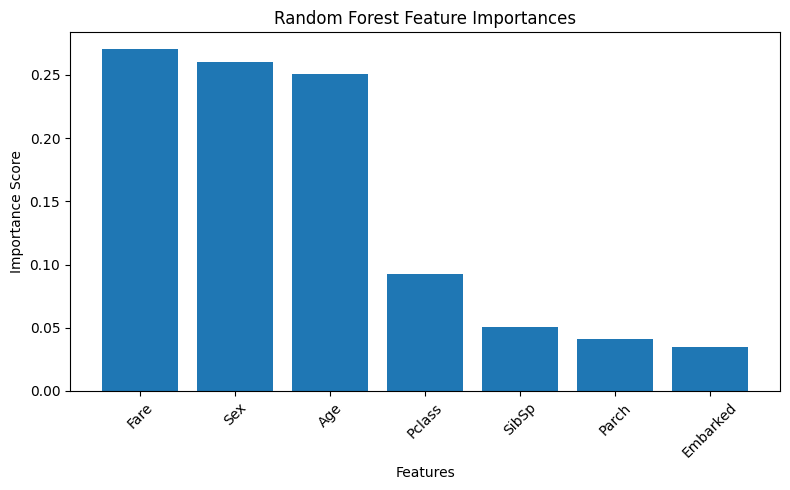

In [19]:
# Get feature importance values from Random Forest
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort features from most important to least important
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance table
print(rf_importance)

# Create the feature importance plot
plt.figure(figsize=(8, 5))

plt.bar(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Random Forest Feature Importances")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Step 11: Random Forest Feature Importance

The feature importance scores were extracted from the trained Random Forest model and visualized using a bar chart.

Feature importance shows the relative contribution of each input feature to the model's predictions. Features with higher importance scores had a greater influence on the Random Forest model.

    Feature  Importance
1       Sex    0.607051
0    Pclass    0.184318
6  Embarked    0.050192
2       Age    0.049569
3     SibSp    0.049416
5      Fare    0.042894
4     Parch    0.016561


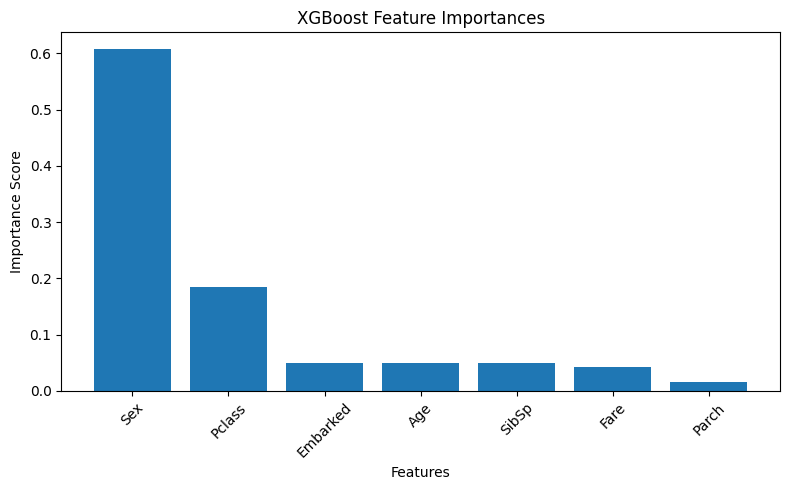

In [20]:
# Get feature importance values from XGBoost
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort features from most important to least important
xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance table
print(xgb_importance)

# Create the feature importance plot
plt.figure(figsize=(8, 5))

plt.bar(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("XGBoost Feature Importances")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Step 12: XGBoost Feature Importance

The feature importance scores were extracted from the trained XGBoost model and visualized using a bar chart.

The importance scores show which passenger features had the greatest influence on the XGBoost model's predictions. These results will be compared with the Random Forest feature-importance results.

## Step 13: Feature Importance Comparison

The Random Forest model considered **Fare**, **Sex**, and **Age** as the three most important features. In contrast, XGBoost considered **Sex** as the most important feature by a large margin, followed by **Pclass** and **Embarked**.

Both models identified **Sex** as an important feature, but they assigned importance differently. Random Forest distributed importance more evenly across several features, while XGBoost placed much greater importance on **Sex**.

## Step 14: Difference Between Random Forest and XGBoost

Random Forest builds many decision trees independently and combines their predictions using majority voting. Each tree is trained separately using different random samples and features. In contrast, XGBoost builds decision trees sequentially, where each new tree focuses on correcting the errors made by previous trees. Random Forest uses a bagging approach, while XGBoost uses a boosting approach to improve model performance.

## Step 15: Final Conclusion

In this task, Logistic Regression, Random Forest, and XGBoost were trained and compared using the Titanic dataset. Random Forest achieved the highest accuracy of **82.68%**, followed by Logistic Regression with **80.45%**, while XGBoost achieved **78.21%**.

The feature-importance analysis showed that Random Forest considered **Fare**, **Sex**, and **Age** the most important features, whereas XGBoost gave the highest importance to **Sex**, followed by **Pclass** and **Embarked**. This experiment demonstrated that ensemble models can provide strong predictions, but their performance depends on the dataset, preprocessing, and model settings.